In [1]:
%run general_functions.ipynb

In [2]:
# variable units
units = var_units()
# labels
lat_labels, lon_labels = lat_lon_labels()

In [3]:
def month_x_labels(ax):
    
    month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']
    ax.set_xticks(np.arange(1, 13, 1))
    ax.set_xticklabels(month_label, fontsize=12)

In [4]:
path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/'

In [5]:
alk_mask = xr.open_dataset(path+'alk_mask/alkalinity_mask_y2035.nc')
mesh_mask = xr.open_dataset(path+'last_decade/mesh_mask.nc')

In [6]:
ns_coords = mesh_mask.where((-40 < mesh_mask.nav_lon) & (mesh_mask.nav_lon < 30) & (30 < mesh_mask.nav_lat) & (mesh_mask.nav_lat < 90), drop=True)

In [7]:
oae = (alk_mask['alk_flux']+mesh_mask['tmask']).isel(t=0,z=0)
oae = xr.where(oae == 1, np.nan, oae)
oae = xr.where(oae == 0, 1, oae)    # first replace 0 with 1
oae = oae.where((-40 < oae.nav_lon) & (oae.nav_lon < 30) & (30 < oae.nav_lat) & (oae.nav_lat < 90), drop=True)
oae = oae.where(oae)

In [8]:
dic = xr.open_dataset(path+'last_decade/dic_baseline_126.nc')
co2flux = xr.open_dataset(path+'last_decade/co2flux_baseline_126.nc')
mld = xr.open_dataset(path+'last_decade/mld_baseline_126.nc')
npp = xr.open_dataset(path+'last_decade/npp_baseline_126.nc')
sst = xr.open_dataset(path+'last_decade/sst_baseline_126.nc')

In [9]:
sliced_mesh = mesh_mask.tmask.isel(t=0,z=0).sel(x=slice(520, 595), y=slice(330, 435))
sliced_mesh = sliced_mesh.where(sliced_mesh)

In [10]:
def geo_weight(data, var):
    data_path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/last_decade/'

    mesh_mask = xr.open_dataset(data_path+'mesh_mask.nc').isel(t=0)
    
    if var in ['sosstsst','bgc_diag_pp']:
        t = mesh_mask.sel(x=slice(520, 596), y=slice(330, 436)) # m-2
    else:
        t = mesh_mask.sel(x=slice(520, 595), y=slice(330, 435)) # m-2

    weights = t.e1t
    zonal_mean = data.weighted(weights).mean(dim='x')
    lat_mean = data['nav_lat'].weighted(weights).mean(dim='x')
    zonal_mean = zonal_mean.assign_coords(lat=lat_mean)

    return zonal_mean

In [11]:
def ns_polygon(data):
    
    # polygon_coords = [(70, 90),(78, 96),(93, 73),(94, 75),(80, 57),(65, 80)] # this is for alkalinity plot
    
    polygon_coords = [(42,70),(55, 80), (69, 53), (58, 34),(41, 61)] # this is for the baseline plot
    
    x = data['x'].values
    y = data['y'].values
    
    X, Y = np.meshgrid(x, y)
    points = np.vstack((X.ravel(), Y.ravel())).T
    
    poly_path = Path(polygon_coords)
    ns_mask = poly_path.contains_points(points).reshape(X.shape)

    return ns_mask

In [12]:
def depth_mask(data, var, depth):
    
    d = copy.deepcopy(data)
    attrs = d[var].attrs.copy()
    mask = ns_polygon(d)
    d = (d * mask).isel(t=0)

    d = d.where(d)

    d[var] = d[var].notnull().astype(int)
    
    mask_sum = d[var].sum(dim=depth).astype(int)

    depth_levels = xr.DataArray(data[depth].values, dims=[depth], coords={depth: data[depth]})
    mask_depth_values = mask_sum.copy()

    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)

    mask_ds = mask_depth_values.to_dataset(name='z')
    mask_ds = mask_ds.where(mask_ds['z'].notnull())

    mask_ds = (mask_ds * mask)
    mask_ds = mask_ds.where(mask_ds)

    return mask_ds

In [13]:
bathymetry = depth_mask(ns_coords, 'tmask', 'z')

In [14]:
zipped = list(zip(mesh_mask.tmask.z, mesh_mask.nav_lev))

In [15]:
mapping = {float(z_item.values): float(nav_lev_item) for z_item, nav_lev_item in zipped}

In [16]:
replace_func = np.vectorize(lambda x: mapping.get(x, np.nan))

In [17]:
bathymetry['z'] = xr.DataArray(
    replace_func(bathymetry['z'].values),  # apply mapping
    coords=bathymetry['z'].coords,         # preserve coordinates
    dims=bathymetry['z'].dims,             # preserve dimensions
    attrs=bathymetry['z'].attrs            # preserve attributes
)

In [18]:
def slicing(data, mld, var):
    
    mld_bool = (data['deptht'] < mld.somxl010).to_dataset(name='mld') 
    data *= mld_bool['mld']
    data = data.where(data).fillna(0)
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    
    weighted_var = (sum(layers_sum) / mld.somxl010).to_dataset(name=var)
    
    return weighted_var

In [19]:
def monthly_means(data, var):

    attrs = data[var].attrs
    
    if 'deptht' in data.dims:
        data = data.isel(deptht=0)
        
    mask = ns_polygon(data)
    # if var == 'DIC':
    #     data = slicing(data, mld, var)

    data = data.sel(time_counter=slice('2090','2100'))

    data = data.where(data)
    data[var] = data[var].transpose('time_counter','y','x')

    data[var] = data[var].where(mask)
    data = geo_weight(data[var], var).to_dataset(name=var)

    m_lenght = data[var].time_counter.dt.days_in_month
    data[var] = (data[var] * m_lenght).groupby("time_counter.month").mean(dim="time_counter") / m_lenght.groupby("time_counter.month").mean(dim="time_counter")

    data[var].attrs = attrs

    return data

In [20]:
def homvoller(data, var, ax, vmin, vmax):
    
    im = data[var].T.plot(
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    if var == 'co2flux':
        extend = 'both'
    else:
        extend = 'max'
        
    c = plt.colorbar(im, ax=ax, aspect=12, pad=0.02, location='top', extend=extend)                       
    c.outline.set_linewidth(0.25)
    c.ax.tick_params(labelsize=13)

    c.set_label(
            f"{list(units[var].keys())[0]} [ {list(units[var].values())[0]} ]",
            labelpad=15, size=18
        )
    
    return im

In [21]:
cmap, norm = create_discrete_cmap(cm.rainforest_r,40)

In [22]:
mld_f = monthly_means(mld, 'somxl010')
npp_f = monthly_means(npp, 'bgc_diag_pp')
sst_f = monthly_means(sst, 'sosstsst')
co2flux_f = monthly_means(co2flux, 'co2flux')
# dic_f = monthly_means(dic, 'DIC')

In [23]:
d = '$^\circ$'

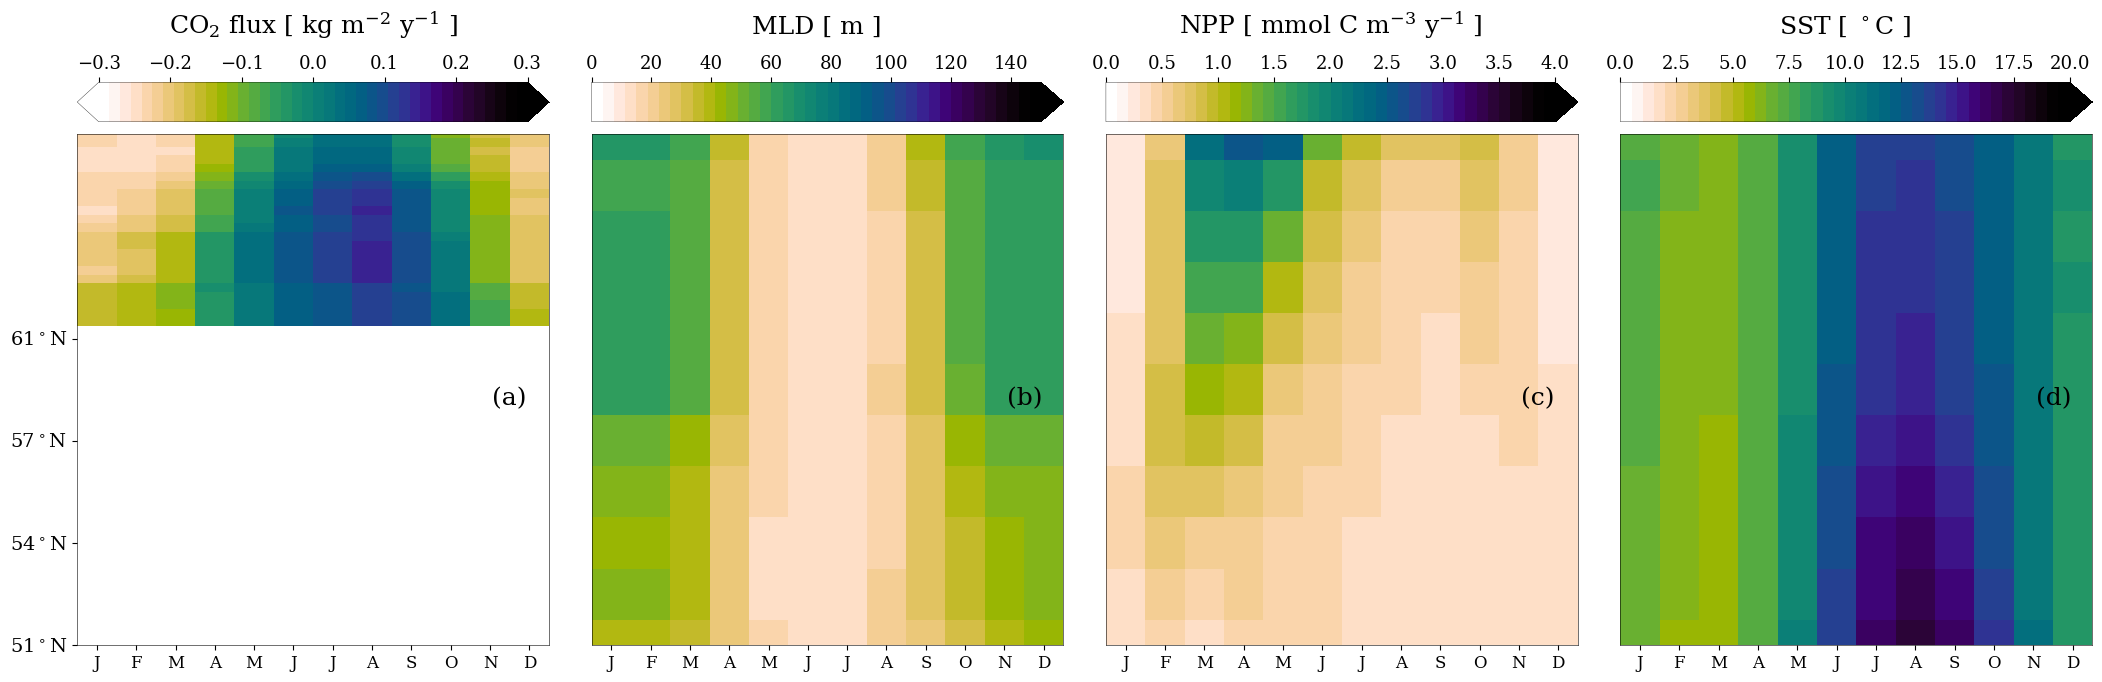

In [27]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    ncols=4,
    figsize=(26, 8),
    # gridspec_kw={'width_ratios': [1.5, 1, 1, 1]}
)

plt.subplots_adjust(wspace=0.09)

# im = ax1.pcolormesh(bathymetry.x, bathymetry.y,
#         bathymetry['z'],
#         cmap=cmap,
#         vmin=0,
#         vmax=300
#     )

# pcm = ax1.pcolormesh(
#     oae.x, oae.y, oae,
#     cmap=sns.cubehelix_palette(start=0, rot=-.5, as_cmap=True),
#     shading='auto',
# )

rect = mpatches.Rectangle((24, 18), 75, 103, linewidth=2, edgecolor='darkred', facecolor='none')
rect = ax1.add_patch(rect)

                            # year
im_co2flux = homvoller(co2flux_f*31536000, 'co2flux', ax1, -0.3, 0.3)
im_mld = homvoller(mld_f, 'somxl010', ax2, 0, 150)
im_npp = homvoller(npp_f*31536000, 'bgc_diag_pp', ax3, 0, 4)
im_sst = homvoller(sst_f, 'sosstsst', ax4, 0, 20)

# cbar = plt.colorbar(im, ax=ax1, aspect=18, pad=0.02, location='top', extend='max')
# cbar.outline.set_linewidth(0.25)
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label('North Sea bathymetry [m]', labelpad=14)

for ax in [ax1,ax2,ax3,ax4]:
    ax.set_ylim(51,61)
    month_x_labels(ax)

for ax in [ax2,ax3,ax4]:    
    ax.axes.get_yaxis().set_visible(False)

for n, ax in enumerate([ax1,ax2,ax3,ax4]):
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")
    for location in ['left','bottom', 'right', 'top']:
        ax.spines[location].set_linewidth(0.4)
    ax.text(0.88, .47, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
        transform=ax.transAxes, size=18, color='black')
    
    
ax1.set_yticks([1,13,25,37])
ns_labels = [f'51{d}N', f'54{d}N',f'57{d}N', f'61{d}N']
ax1.set_yticklabels(ns_labels, fontsize=14)

pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_2.png')

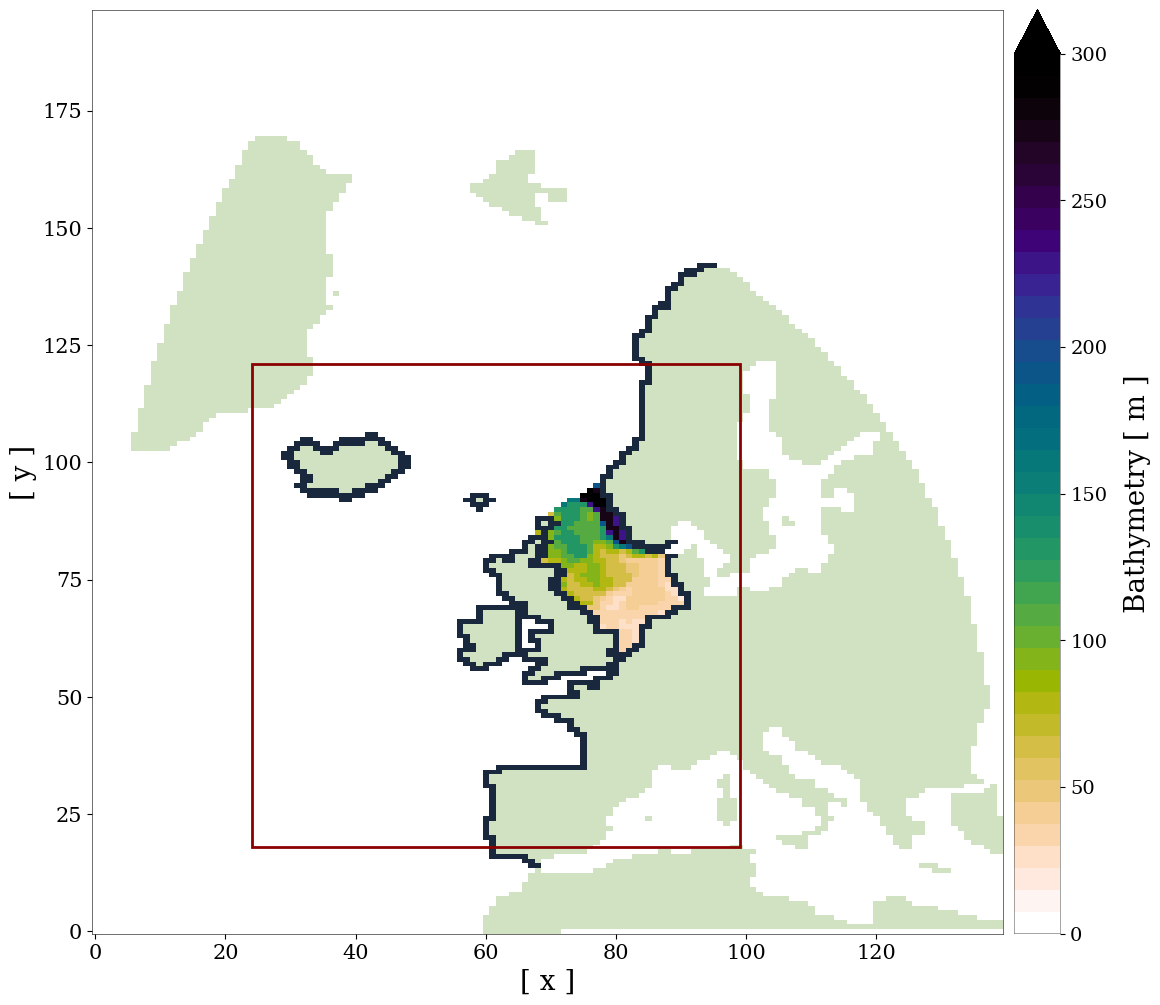

In [150]:
# Create figure
fig, ax1 = plt.subplots(figsize=(14,12))

im = ax1.pcolormesh(bathymetry.x, bathymetry.y,
        bathymetry['z'],
        cmap=cmap,
        vmin=0,
        vmax=300
    )

pcm = ax1.pcolormesh(
    oae.x, oae.y, oae,
    cmap=sns.cubehelix_palette(start=0, rot=-.5, as_cmap=True),
    shading='auto',
)

cbar = plt.colorbar(im, ax=ax1, aspect=20, pad=0.01, location='right', extend='max')
cbar.outline.set_linewidth(0.25)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Bathymetry [ m ]', labelpad=12)

rect = mpatches.Rectangle((24, 18), 75, 103, linewidth=2, edgecolor='darkred', facecolor='none')
rect = ax1.add_patch(rect)

                            # year
# im_co2flux = homvoller(co2flux_f*31536000, 'co2flux', ax2, -0.3, 0.3)
# im_mld = homvoller(mld_f, 'somxl010', ax3, 0, 150)
# im_npp = homvoller(npp_f*31536000, 'bgc_diag_pp', ax4, 0, 4)
# im_sst = homvoller(sst_f, 'sosstsst', ax5, 0, 20)

for location in ['left','bottom', 'right', 'top']:
    ax1.spines[location].set_linewidth(0.4)
    
ax1.set_ylabel('[ y ]')
ax1.set_xlabel('[ x ]')
    
plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_1.png')